In [3]:
#可调整参数：
#滞后窗口长度：日滞后：通常固定为 1 天；周滞后：通常取过去 5 天的平均（对应一周交易日），也可根据市场特性调整为 7 天（加密货币 7×24 小时）；月滞后：通常取过去 22 天（对应一个月交易日），或调整为 30 天。
#是否对 RV 进行变换：可以直接使用 RV，也可以取对数（log(RV)）或平方根（sqrt(RV)）以稳定方差和改善模型拟合。
#是否包含其他预测变量：如跳跃成分、杠杆效应等，可作为扩展模型的附加参数。

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.api import OLS, add_constant
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

#1. 加载1分钟数据 
print("正在加载数据...")
# 注意：如果内存不足，可指定 dtype 优化，例如 float32
df = pd.read_csv("../data/btcusd_1-min_data.csv")

# 转换时间戳并设置为索引
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df.set_index('Timestamp', inplace=True)
df.sort_index(inplace=True)

print(f"数据时间范围：{df.index.min()} 至 {df.index.max()}")
print(f"总行数：{len(df)}")



正在加载数据...
数据时间范围：2012-01-01 10:01:00 至 2026-01-26 23:59:00
总行数：7399839


In [4]:
#2. 计算分钟收益率 
df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))

#3. 计算日度已实现波动率 (RV)
# 按天聚合，计算每日分钟收益率的平方和（即已实现方差）
daily_rv = df['log_ret'].resample('D').apply(lambda x: np.sum(x**2))

# 统计每天的实际分钟数（剔除数据不足的天）
daily_counts = df['log_ret'].resample('D').count()
min_obs = 1000  # 阈值：一天至少需要1000个分钟数据（约70%）
daily_rv[daily_counts < min_obs] = np.nan

# 计算日收益率（可选，用于基准模型，这里不直接使用）
# daily_close = df['Close'].resample('D').last()
# daily_ret = np.log(daily_close / daily_close.shift(1))

# 转换为DataFrame并去除缺失值
rv = daily_rv.to_frame(name='rv').dropna()
print(f"有效日度RV数据量：{len(rv)}")
print(rv.head())



有效日度RV数据量：5138
                  rv
Timestamp           
2012-01-02  0.001058
2012-01-03  0.007253
2012-01-04  0.009645
2012-01-05  0.003875
2012-01-06  0.003701


In [5]:
#4. 构建HAR-RV特征
# HAR-RV 使用日滞后、周平均、月平均
# 注意：周平均为过去5天（不含当天），月平均为过去22天

df_har = rv.copy()
df_har['rv_lag1'] = df_har['rv'].shift(1)                     # RV_{t-1}
df_har['rv_week'] = df_har['rv'].rolling(5).mean().shift(1)   # (RV_{t-5}+...+RV_{t-1})/5
df_har['rv_month'] = df_har['rv'].rolling(22).mean().shift(1) # (RV_{t-22}+...+RV_{t-1})/22

# 删除因滚动窗口产生的缺失值（需要至少22个前期观测）
df_har.dropna(inplace=True)
print(f"构建特征后数据量：{len(df_har)}")



构建特征后数据量：5116


In [6]:
#5. 划分训练集和测试集
# 按时间顺序划分，前80%训练，后20%测试
train_size = int(0.8 * len(df_har))
train = df_har.iloc[:train_size]
test = df_har.iloc[train_size:]

print(f"训练集：{train.index[0]} 至 {train.index[-1]}，共 {len(train)} 天")
print(f"测试集：{test.index[0]} 至 {test.index[-1]}，共 {len(test)} 天")



训练集：2012-01-24 00:00:00 至 2023-04-07 00:00:00，共 4092 天
测试集：2023-04-08 00:00:00 至 2026-01-26 00:00:00，共 1024 天


In [7]:
#6. OLS估计HAR-RV模型
# 定义自变量（需添加截距）
X_train = train[['rv_lag1', 'rv_week', 'rv_month']]
X_train = add_constant(X_train)
y_train = train['rv']

# 模型拟合
model = OLS(y_train, X_train).fit()
print(model.summary())

# 保存系数
coef = model.params
print("\n估计系数：")
print(coef)

#7. 样本外预测
X_test = test[['rv_lag1', 'rv_week', 'rv_month']]
X_test = add_constant(X_test)
y_pred = model.predict(X_test)
y_true = test['rv']

# 将预测值转为Series，便于后续处理
pred_har = pd.Series(y_pred.values, index=test.index, name='har_pred')



                            OLS Regression Results                            
Dep. Variable:                     rv   R-squared:                       0.437
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     1057.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        09:08:47   Log-Likelihood:                 9664.2
No. Observations:                4092   AIC:                        -1.932e+04
Df Residuals:                    4088   BIC:                        -1.930e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.000      3.484      0.0


HAR-RV 样本外误差：
  MSE   = 0.000002
  MAE   = 0.001248
  QLIKE = 0.799310

=== 模型对比（共同测试区间） ===
GARCH(1,1): MSE=0.000000, MAE=0.000438, QLIKE=0.362871
EWMA      : MSE=0.000000, MAE=0.000343, QLIKE=0.333449
HAR-RV    : MSE=0.000002, MAE=0.001251, QLIKE=0.800097

HAR-RV 相比 GARCH 的 MSE 降低: -304.87%

训练残差 Ljung-Box 检验：
       lb_stat      lb_pvalue
10  619.038647  1.464321e-126
20  643.979540  1.530057e-123


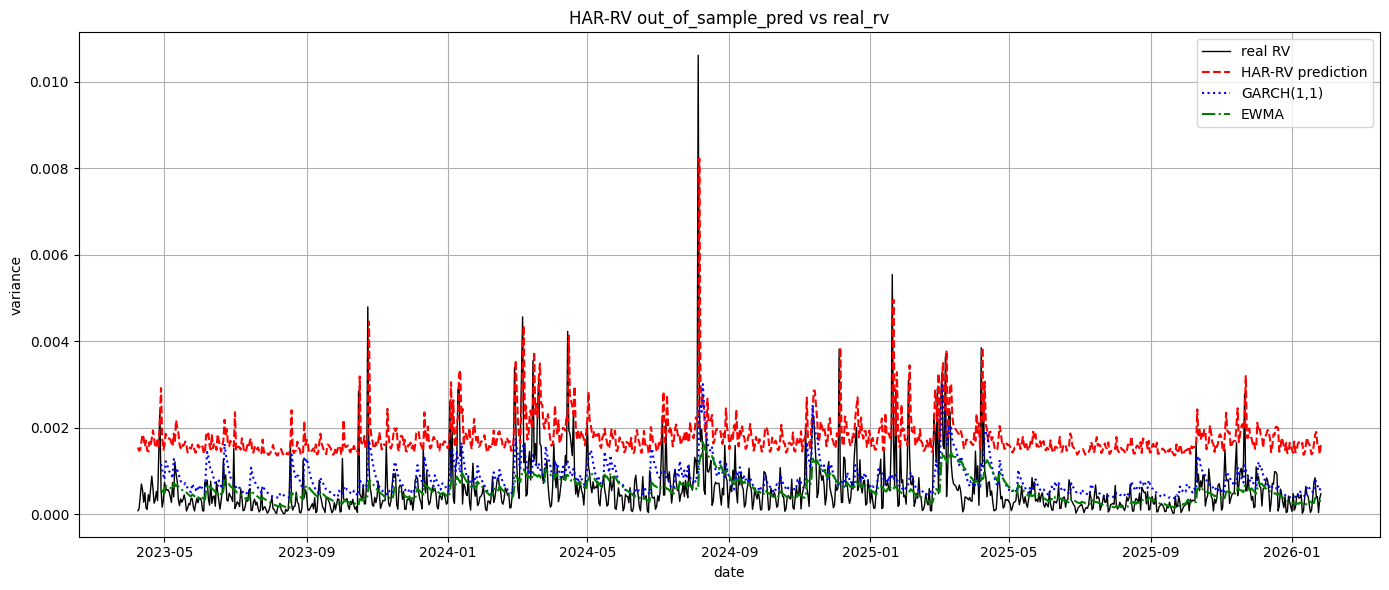


HAR-RV预测结果已保存至 har_predictions.csv


In [8]:
#8. 误差评估
def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    # QLIKE损失函数：mean( true/pred - log(true/pred) - 1 )
    # 需确保预测值>0
    if (y_pred <= 0).any():
        qlike = np.nan
        print("警告：预测值非正，QLIKE无法计算")
    else:
        qlike = np.mean(y_true / y_pred - np.log(y_true / y_pred) - 1)
    return mse, mae, qlike

mse_h, mae_h, qlike_h = compute_metrics(y_true, y_pred)
print("\nHAR-RV 样本外误差：")
print(f"  MSE   = {mse_h:.6f}")
print(f"  MAE   = {mae_h:.6f}")
print(f"  QLIKE = {qlike_h:.6f}")

#9. （可选）与基准模型比较 ====================
# 注意：该文件的日期应与 test 的索引对齐

try:
    bench = pd.read_csv('../data/benchmark_predictions.csv', parse_dates=['date'])
    bench.set_index('date', inplace=True)

    # 对齐索引（取共同部分）
    common_idx = test.index.intersection(bench.index)
    if len(common_idx) > 0:
        y_true_common = y_true.loc[common_idx]
        pred_garch = bench.loc[common_idx, 'garch_pred']
        pred_ewma = bench.loc[common_idx, 'ewma_pred']
        pred_har_common = pred_har.loc[common_idx]

        mse_g, mae_g, qlike_g = compute_metrics(y_true_common, pred_garch)
        mse_e, mae_e, qlike_e = compute_metrics(y_true_common, pred_ewma)
        mse_hc, mae_hc, qlike_hc = compute_metrics(y_true_common, pred_har_common)

        print("\n=== 模型对比（共同测试区间） ===")
        print(f"GARCH(1,1): MSE={mse_g:.6f}, MAE={mae_g:.6f}, QLIKE={qlike_g:.6f}")
        print(f"EWMA      : MSE={mse_e:.6f}, MAE={mae_e:.6f}, QLIKE={qlike_e:.6f}")
        print(f"HAR-RV    : MSE={mse_hc:.6f}, MAE={mae_hc:.6f}, QLIKE={qlike_hc:.6f}")

        # 计算百分比改进
        impr_g = (mse_g - mse_hc) / mse_g * 100
        print(f"\nHAR-RV 相比 GARCH 的 MSE 降低: {impr_g:.2f}%")
    else:
        print("基准预测文件日期与测试集不重叠，无法比较")
except FileNotFoundError:
    print("未找到基准预测文件 benchmark_predictions.csv，跳过比较")

#10. 残差诊断
from statsmodels.stats.diagnostic import acorr_ljungbox

resid_train = model.resid
lb_test = acorr_ljungbox(resid_train, lags=[10, 20], return_df=True)
print("\n训练残差 Ljung-Box 检验：")
print(lb_test)
# 若p值>0.05，则残差无自相关，模型充分

#可视化对比
plt.figure(figsize=(14,6))
plt.plot(y_true.index, y_true, label='real RV', color='black', linewidth=1)
plt.plot(pred_har.index, pred_har, label='HAR-RV prediction', color='red', linestyle='--')
# 如果有基准预测，也可添加
try:
    if 'pred_garch' in locals():
        plt.plot(pred_garch.index, pred_garch, label='GARCH(1,1)', color='blue', linestyle=':')
    if 'pred_ewma' in locals():
        plt.plot(pred_ewma.index, pred_ewma, label='EWMA', color='green', linestyle='-.')
except:
    pass
plt.legend()
plt.title('HAR-RV out_of_sample_pred vs real_rv')
plt.xlabel('date')
plt.ylabel('variance')
plt.grid(True)
plt.tight_layout()
plt.savefig('har_rv_comparison.png', dpi=150)
plt.show()

#保存预测结果
# 保存HAR-RV预测值（以及真实值）到CSV
output = pd.DataFrame({
    'date': y_true.index,
    'true_rv': y_true.values,
    'har_pred': y_pred.values
})
output.to_csv('har_predictions.csv', index=False)
print("\nHAR-RV预测结果已保存至 har_predictions.csv")

In [9]:
import numpy as np

def compute_metrics(y_true, y_pred):
    """
    计算MSE, MAE, QLIKE
    参数:
        y_true: 真实值 (numpy数组或pandas Series)
        y_pred: 预测值 (numpy数组或pandas Series)
    返回:
        mse, mae, qlike
    """
    # 确保为numpy数组
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    # MSE, MAE
    mse = np.mean((y_true - y_pred)**2)
    mae = np.mean(np.abs(y_true - y_pred))
    
    # QLIKE
    # 防止预测值为0或负，设置下限
    y_pred_safe = np.maximum(y_pred, 1e-8)
    ratio = y_true / y_pred_safe
    qlike = np.mean(ratio - np.log(ratio) - 1)
    
    return mse, mae, qlike

In [10]:
mse, mae, qlike = compute_metrics(y_true, y_pred)
print(f"MSE = {mse:.6f}, MAE = {mae:.6f}, QLIKE = {qlike:.6f}")

MSE = 0.000002, MAE = 0.001248, QLIKE = 0.799310


In [11]:
results_summary = pd.DataFrame({
    'Model': ['GARCH(1,1)', 'EWMA', 'HAR-RV'],
    'MSE': [mse_g, mse_e, mse_h],
    'MAE': [mae_g, mae_e, mae_h],
    'QLIKE': [qlike_g, qlike_e, qlike_h]
})
print(results_summary)

        Model           MSE       MAE     QLIKE
0  GARCH(1,1)  4.438437e-07  0.000438  0.362871
1        EWMA  4.158686e-07  0.000343  0.333449
2      HAR-RV  1.789837e-06  0.001248  0.799310
